## Import Data and Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.metrics import mean_squared_error, r2_score

df = pd.read_csv('https://raw.githubusercontent.com/yaduk29/carpricedataset1/main/test.csv')

In [2]:
df.head()

,id,car_name,yr_mfr,fuel_type,kms_run,sale_price,city,times_viewed,body_type,transmission,...,total_owners,broker_quote,original_price,car_rating,ad_created_on,fitness_certificate,emi_starts_from,booking_down_pymnt,reserved,warranty_avail
0,1,maruti swift dzire,2012,petrol,69029,364299,pune,2068,sedan,manual,...,3,363529,365029.0,great,2021-03-16T05:00:49.555,True,8462,54645,False,False
1,2,hyundai eon,2013,petrol,45721,216799,gurgaon,903,hatchback,manual,...,1,205738,NaN,great,2021-03-10T12:08:11.905,True,5036,32520,False,False
2,3,honda amaze,2013,diesel,37395,387399,pune,2809,sedan,manual,...,1,382667,NaN,great,2021-03-15T12:03:30.041,True,8998,58110,True,False
3,4,hyundai i20,2012,petrol,37652,364699,bengaluru,1054,hatchback,manual,...,3,335740,NaN,great,2021-04-09T11:16:26.157,True,8471,54705,True,False
4,5,hyundai creta,2017,diesel,53648,1082011,lucknow,2927,suv,automatic,...,1,1119840,1125840.0,great,2021-04-01T07:24:31.712,True,25132,162302,False,False


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 30 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   id                   1000 non-null   int64  
 1   car_name             1000 non-null   object 
 2   yr_mfr               1000 non-null   int64  
 3   fuel_type            1000 non-null   object 
 4   kms_run              1000 non-null   int64  
 5   sale_price           1000 non-null   int64  
 6   city                 1000 non-null   object 
 7   times_viewed         1000 non-null   int64  
 8   body_type            987 non-null    object 
 9   transmission         918 non-null    object 
 10  variant              1000 non-null   object 
 11  assured_buy          1000 non-null   bool   
 12  registered_city      998 non-null    object 
 13  registered_state     998 non-null    object 
 14  is_hot               1000 non-null   bool   
 15  rto                  1000 non-null   ob

In [4]:
df.isnull().sum()

,0
id,0
car_name,0
yr_mfr,0
fuel_type,0
kms_run,0
sale_price,0
city,0
times_viewed,0
body_type,13
transmission,82


## Handling missing values


In [5]:
# Group by 'make' and calculate the mean of 'original_price'
mean_prices = df.groupby('make')['original_price'].mean()

# Fill missing values in 'original_price' based on the corresponding 'make'
df['original_price'] = df.apply(
    lambda row: mean_prices[row['make']] if pd.isnull(row['original_price']) else row['original_price'], axis=1
)

# Check for makes with still missing values in 'original_price'
missing_makes = df[df['original_price'].isnull()]['make'].unique()
print("Makes with missing original_price values:", missing_makes)

# Fill remaining missing values in 'original_price' with the overall mean as a fallback
overall_mean = df['original_price'].mean()
df['original_price'] = df['original_price'].fillna(overall_mean)

# Fill missing values for other columns
for col in df.columns:
    if df[col].isnull().sum() > 0:  # Check if there are missing values
        if df[col].dtype in ['float64', 'int64']:
            # Fill numeric columns with the mean
            mean_value = df[col].mean()
            df[col] = df[col].fillna(mean_value)
        elif df[col].dtype == 'object':
            # Fill categorical columns with the mode
            mode_value = df[col].mode()[0]  # Get the first mode
            df[col] = df[col].fillna(mode_value)



Makes with missing original_price values: ['chevrolet' 'bmw' 'jaguar' 'mahindra renault']


In [6]:
pd.options.display.float_format = '{:.2f}'.format
df.head()

,id,car_name,yr_mfr,fuel_type,kms_run,sale_price,city,times_viewed,body_type,transmission,...,total_owners,broker_quote,original_price,car_rating,ad_created_on,fitness_certificate,emi_starts_from,booking_down_pymnt,reserved,warranty_avail
0,1,maruti swift dzire,2012,petrol,69029,364299,pune,2068,sedan,manual,...,3,363529,365029.00,great,2021-03-16T05:00:49.555,True,8462,54645,False,False
1,2,hyundai eon,2013,petrol,45721,216799,gurgaon,903,hatchback,manual,...,1,205738,551695.53,great,2021-03-10T12:08:11.905,True,5036,32520,False,False
2,3,honda amaze,2013,diesel,37395,387399,pune,2809,sedan,manual,...,1,382667,542803.05,great,2021-03-15T12:03:30.041,True,8998,58110,True,False
3,4,hyundai i20,2012,petrol,37652,364699,bengaluru,1054,hatchback,manual,...,3,335740,551695.53,great,2021-04-09T11:16:26.157,True,8471,54705,True,False
4,5,hyundai creta,2017,diesel,53648,1082011,lucknow,2927,suv,automatic,...,1,1119840,1125840.00,great,2021-04-01T07:24:31.712,True,25132,162302,False,False


In [ ]:
df.isnull().sum()

,0
id,0
car_name,0
yr_mfr,0
fuel_type,0
kms_run,0
sale_price,0
city,0
times_viewed,0
body_type,0
transmission,0


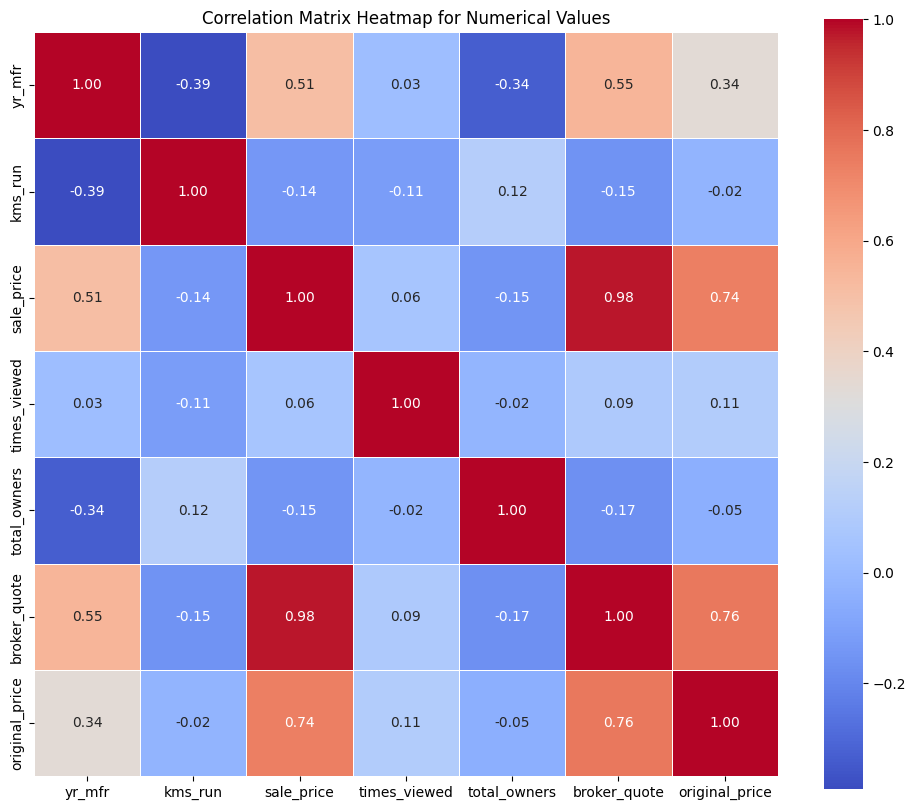

In [ ]:
numerical_df = df.select_dtypes(include=['number'])

# Calculate the correlation matrix for numerical columns
corr = numerical_df.corr()

# Plot the heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', square=True, linewidths=0.5)
plt.title('Correlation Matrix Heatmap for Numerical Values')
plt.show()

In [7]:
# Dropping unnecessary columns
columns_to_drop = ['id', 'car_name', 'rto', 'source', 'ad_created_on',
                   'fitness_certificate', 'assured_buy', 'is_hot',
                   'reserved', 'warranty_avail', 'emi_starts_from',
                   'booking_down_pymnt', 'variant']

df.drop(columns=columns_to_drop, axis=1, inplace=True)

# Verifying the remaining columns
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 17 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   yr_mfr            1000 non-null   int64  
 1   fuel_type         1000 non-null   object 
 2   kms_run           1000 non-null   int64  
 3   sale_price        1000 non-null   int64  
 4   city              1000 non-null   object 
 5   times_viewed      1000 non-null   int64  
 6   body_type         1000 non-null   object 
 7   transmission      1000 non-null   object 
 8   registered_city   1000 non-null   object 
 9   registered_state  1000 non-null   object 
 10  make              1000 non-null   object 
 11  model             1000 non-null   object 
 12  car_availability  1000 non-null   object 
 13  total_owners      1000 non-null   int64  
 14  broker_quote      1000 non-null   int64  
 15  original_price    1000 non-null   float64
 16  car_rating        1000 non-null   object 
d

In [ ]:
df.head()

,yr_mfr,fuel_type,kms_run,sale_price,city,times_viewed,body_type,transmission,registered_city,registered_state,make,model,car_availability,total_owners,broker_quote,original_price,car_rating
0,2012,petrol,69029,364299,pune,2068,sedan,manual,pune,maharashtra,maruti,swift dzire,in_stock,3,363529,3.650290e+05,great
1,2013,petrol,45721,216799,gurgaon,903,hatchback,manual,delhi,delhi,hyundai,eon,in_stock,1,205738,5.516955e+05,great
2,2013,diesel,37395,387399,pune,2809,sedan,manual,mumbai,maharashtra,honda,amaze,in_stock,1,382667,5.428030e+05,great
3,2012,petrol,37652,364699,bengaluru,1054,hatchback,manual,bengaluru,karnataka,hyundai,i20,in_transit,3,335740,5.516955e+05,great
4,2017,diesel,53648,1082011,lucknow,2927,suv,automatic,lucknow,uttar pradesh,hyundai,creta,in_stock,1,1119840,1.125840e+06,great


In [ ]:
df.describe()

,yr_mfr,kms_run,sale_price,times_viewed,total_owners,broker_quote,original_price
count,1000.00000,1000.000000,1.000000e+03,1000.000000,1000.000000,1.000000e+03,1.000000e+03
mean,2013.81700,64200.546000,4.564917e+05,1649.047000,1.336000,4.340296e+05,5.562898e+05
std,3.08367,46279.250371,3.116202e+05,2703.996647,0.611128,3.049773e+05,2.553989e+05
min,2002.00000,379.000000,3.500000e+04,6.000000,1.000000,0.000000e+00,9.689900e+04
25%,2012.00000,33159.500000,2.727740e+05,556.000000,1.000000,2.464942e+05,4.416945e+05
50%,2014.00000,56880.000000,3.836490e+05,1155.500000,1.000000,3.618295e+05,4.992835e+05
75%,2016.00000,84372.500000,5.433740e+05,2036.500000,2.000000,5.267560e+05,5.781988e+05
max,2020.00000,640251.000000,3.866000e+06,61930.000000,5.000000,3.250000e+06,2.706469e+06


## Encoding Categorical Variables
Convert categorical variables into numerical format using One-Hot Encoding:

In [ ]:
import pandas as pd

# Assuming your DataFrame is named df
# Perform one-hot encoding on the object columns
df_encoded = pd.get_dummies(df, columns=df.select_dtypes(include=['object']).columns, drop_first=True)
df=df_encoded
# Check the updated DataFrame info
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Columns: 260 entries, yr_mfr to car_rating_overpriced
dtypes: bool(253), float64(1), int64(6)
memory usage: 301.9 KB
None


In [ ]:
df.head()

,yr_mfr,kms_run,sale_price,times_viewed,total_owners,broker_quote,original_price,fuel_type_electric,fuel_type_petrol,fuel_type_petrol & cng,...,model_xuv500,model_xylo,model_zen estilo,model_zest,car_availability_in_transit,car_availability_out_of_stock,car_availability_pickup_pending,car_rating_good,car_rating_great,car_rating_overpriced
0,2012,69029,364299,2068,3,363529,3.650290e+05,False,True,False,...,False,False,False,False,False,False,False,False,True,False
1,2013,45721,216799,903,1,205738,5.516955e+05,False,True,False,...,False,False,False,False,False,False,False,False,True,False
2,2013,37395,387399,2809,1,382667,5.428030e+05,False,False,False,...,False,False,False,False,False,False,False,False,True,False
3,2012,37652,364699,1054,3,335740,5.516955e+05,False,True,False,...,False,False,False,False,True,False,False,False,True,False
4,2017,53648,1082011,2927,1,1119840,1.125840e+06,False,False,False,...,False,False,False,False,False,False,False,False,True,False


OUTLIERS REMOVAL



```
```



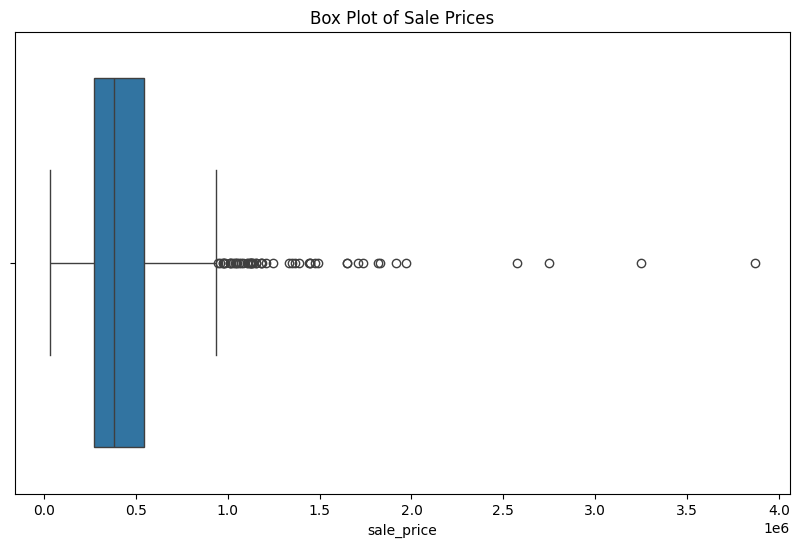

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.boxplot(x=df['sale_price'])
plt.title('Box Plot of Sale Prices')
plt.show()


     yr_mfr  kms_run  sale_price  times_viewed  total_owners  broker_quote  \
0      2012    69029      364299          2068             3        363529   
1      2013    45721      216799           903             1        205738   
2      2013    37395      387399          2809             1        382667   
3      2012    37652      364699          1054             3        335740   
5      2016    55724      695999           889             1        655939   
..      ...      ...         ...           ...           ...           ...   
995    2002    77323       35000           492             2             0   
996    2018    53486      604299          2756             1        630810   
997    2018     8854      562599           640             1        549440   
998    2015    46300      400499           795             1        383419   
999    2016    27245      284099          1155             1        286515   

     original_price  fuel_type_electric  fuel_type_petrol  \
0 

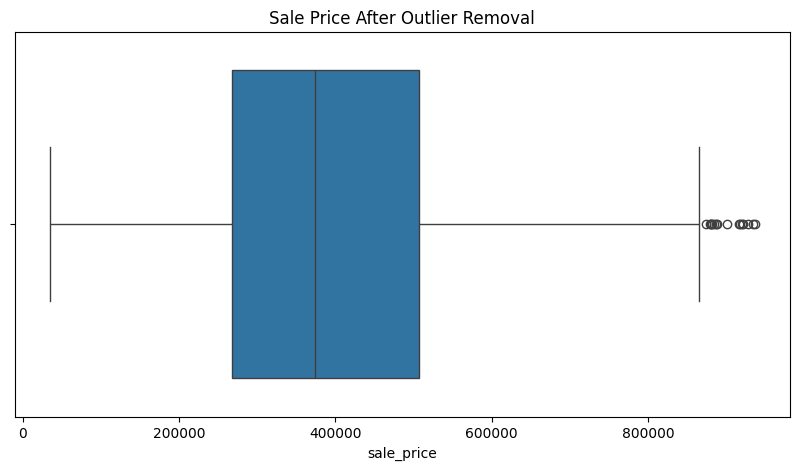

In [ ]:
import pandas as pd

# Assuming df is your DataFrame
# Calculate Q1 (25th percentile) and Q3 (75th percentile)
Q1 = df['sale_price'].quantile(0.25)
Q3 = df['sale_price'].quantile(0.75)

# Calculate the IQR
IQR = Q3 - Q1

# Define upper and lower bounds
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Remove outliers
df_cleaned_iqr = df[(df['sale_price'] >= lower_bound) & (df['sale_price'] <= upper_bound)]
df=df_cleaned_iqr

# Display the cleaned DataFrame
print(df_cleaned_iqr)

# Optionally, you can visualize the cleaned data to confirm
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 5))
sns.boxplot(x=df_cleaned_iqr['sale_price'])
plt.title('Sale Price After Outlier Removal')
plt.show()


## Splitting the Data into Train/Test Sets And Model

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_log_error, r2_score

# Assuming df is your DataFrame and 'sale_price' is the target variable
X = df.drop(columns=['sale_price'])  # Features
y = df['sale_price']  # Target

# Convert categorical columns to numerical using one-hot encoding
X_encoded = pd.get_dummies(X, drop_first=True)

# Split the dataset into training and testing sets
x_train, x_test, y_train, y_test = train_test_split(X_encoded, y, test_size=0.2, random_state=42)

# Train the model
model = RandomForestRegressor(n_estimators=75, max_depth=25, random_state=42)
model.fit(x_train, y_train)

# Make predictions
y_pred = model.predict(x_test)

# Evaluate the model using Mean Squared Log Error
msle = mean_squared_log_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f'Mean Squared Log Error: {msle}')
print(f'R² Score: {r2}')



Mean Squared Log Error: 0.03192202678807932
R² Score: 0.9721420509958123


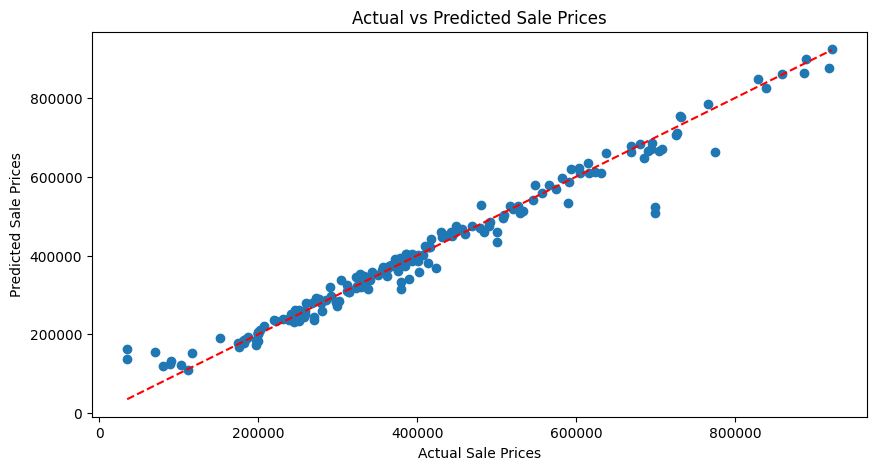

In [ ]:
# Scatter plot of actual vs predicted values
plt.figure(figsize=(10, 5))
plt.scatter(y_test, y_pred)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red', linestyle='--')  # Line of equality
plt.title('Actual vs Predicted Sale Prices')
plt.xlabel('Actual Sale Prices')
plt.ylabel('Predicted Sale Prices')
plt.show()


In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# Assuming df is your DataFrame and 'sale_price' is the target variable
X = df.drop(columns=['sale_price'])  # Features
y = df['sale_price']  # Target

# Convert categorical columns to numerical using one-hot encoding
X_encoded = pd.get_dummies(X, drop_first=True)

# Split the dataset into training and testing sets
x_train, x_test, y_train, y_test = train_test_split(X_encoded, y, test_size=0.2, random_state=42)

# Initialize the model
model = LinearRegression()

# Train the model
model.fit(x_train, y_train)

y_pred = model.predict(x_test)

# Evaluate the model using Mean Squared Log Error
msle = mean_squared_log_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f'Mean Squared Log Error: {msle}')
print(f'R² Score: {r2}')



Mean Squared Log Error: 0.012552273065169397
R² Score: 0.9700114510985471


In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_log_error, r2_score

# Prepare the model
X = df.drop(columns=['sale_price'])
y = df['sale_price']

X_encoded = pd.get_dummies(X, drop_first=True)
x_train, x_test, y_train, y_test = train_test_split(X_encoded, y, test_size=0.2, random_state=42)

# Initialize the Linear Regression model
model = LinearRegression()
model.fit(x_train, y_train)

# Make predictions on the test set
y_pred = model.predict(x_test)

# Calculate R² and MSLE
r2 = r2_score(y_test, y_pred)
msle = mean_squared_log_error(y_test, y_pred)

# Print R² and MSLE without formatting (full precision)
print(f"Mean Squared Logarithmic Error: {msle}")
print(f"R² Score: {r2}")

def predict_sale_price():
    # Get user input
    yr_mfr = int(input("Enter year of manufacture: "))
    fuel_type = input("Enter fuel type (petrol/diesel): ")
    kms_run = int(input("Enter kilometers run: "))
    city = input("Enter city: ")
    times_viewed = int(input("Enter number of times viewed: "))
    body_type = input("Enter body type (sedan/hatchback/suv): ")
    transmission = input("Enter transmission type (manual/automatic): ")
    registered_city = input("Enter registered city: ")
    registered_state = input("Enter registered state: ")
    make = input("Enter make of the car: ")
    model_name = input("Enter model of the car: ")
    car_availability = input("Enter car availability (in_stock/in_transit): ")
    total_owners = int(input("Enter total owners: "))
    broker_quote = float(input("Enter broker quote: "))
    original_price = float(input("Enter original price: "))
    car_rating = input("Enter car rating: ")

    # Create a DataFrame for the input
    input_data = {
        'yr_mfr': [yr_mfr],
        'fuel_type': [fuel_type],
        'kms_run': [kms_run],
        'city': [city],
        'times_viewed': [times_viewed],
        'body_type': [body_type],
        'transmission': [transmission],
        'registered_city': [registered_city],
        'registered_state': [registered_state],
        'make': [make],
        'model': [model_name],
        'car_availability': [car_availability],
        'total_owners': [total_owners],
        'broker_quote': [broker_quote],
        'original_price': [original_price],
        'car_rating': [car_rating],
    }

    input_df = pd.DataFrame(input_data)
    input_encoded = pd.get_dummies(input_df, drop_first=True)

    # Align the input data with the model's training data
    input_encoded = input_encoded.reindex(columns=X_encoded.columns, fill_value=0)

    # Make prediction
    predicted_price = model.predict(input_encoded)
    print(f"Predicted Sale Price: {predicted_price[0]:.2f}")  # Predicted price with 2 decimal points

# Call the function
predict_sale_price()


Mean Squared Logarithmic Error: 0.012552273065169397
R² Score: 0.9700114510985471
Enter year of manufacture: 2012
Enter fuel type (petrol/diesel): petrol
Enter kilometers run: 69029
Enter city: pune
Enter number of times viewed: 2068
Enter body type (sedan/hatchback/suv): sedan
Enter transmission type (manual/automatic): manual
Enter registered city: pune
Enter registered state: maharashtra
Enter make of the car: maruti
Enter model of the car: swift dzire
Enter car availability (in_stock/in_transit): in_stock
Enter total owners: 3
Enter broker quote: 363529
Enter original price: 365029.0
Enter car rating: great
Predicted Sale Price: 405567.94


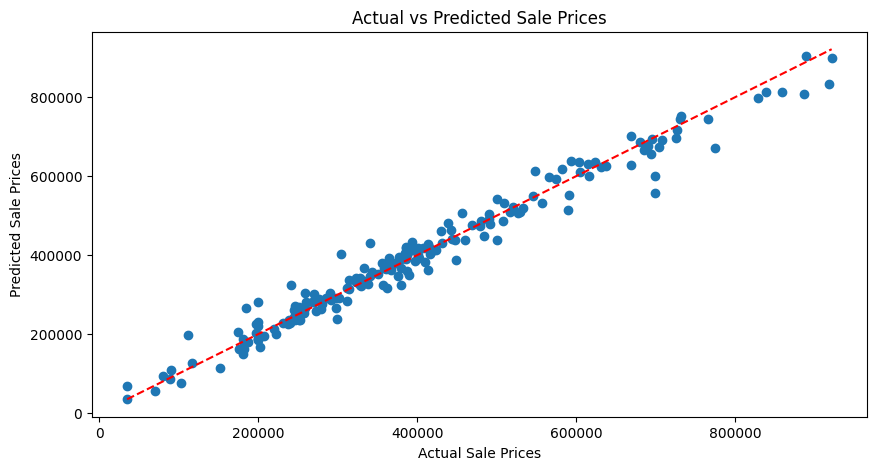

In [ ]:
# Scatter plot of actual vs predicted values
plt.figure(figsize=(10, 5))
plt.scatter(y_test, y_pred)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red', linestyle='--')  # Line of equality
plt.title('Actual vs Predicted Sale Prices')
plt.xlabel('Actual Sale Prices')
plt.ylabel('Predicted Sale Prices')
plt.show()

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_log_error, r2_score
import xgboost as xgb

# Assuming df is your DataFrame and 'sale_price' is the target variable
X = df.drop(columns=['sale_price'])  # Features
y = df['sale_price']  # Target

# Convert categorical columns to numerical using one-hot encoding
X_encoded = pd.get_dummies(X, drop_first=True)

# Split the dataset into training and testing sets
x_train, x_test, y_train, y_test = train_test_split(X_encoded, y, test_size=0.2, random_state=42)

# Initialize the XGBoost model
model = xgb.XGBRegressor()

# Train the model
model.fit(x_train, y_train)

# Make predictions
y_pred = model.predict(x_test)

# Evaluate the model using Mean Squared Log Error
msle = mean_squared_log_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f'Mean Squared Log Error: {msle}')
print(f'R² Score: {r2}')


Mean Squared Log Error: 0.020650059362571162
R² Score: 0.9741156101226807


In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_log_error, r2_score
from sklearn.ensemble import ExtraTreesRegressor

# Assuming df is your DataFrame and 'sale_price' is the target variable
X = df.drop(columns=['sale_price'])  # Features
y = df['sale_price']  # Target

# Convert categorical columns to numerical using one-hot encoding
X_encoded = pd.get_dummies(X, drop_first=True)

# Split the dataset into training and testing sets
x_train, x_test, y_train, y_test = train_test_split(X_encoded, y, test_size=0.2, random_state=42)

# Initialize the Extra Trees Regressor model
model = ExtraTreesRegressor(random_state=42)

# Train the model
model.fit(x_train, y_train)

# Make predictions
y_pred = model.predict(x_test)

# Evaluate the model using Mean Squared Log Error
msle = mean_squared_log_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f'Mean Squared Log Error: {msle}')
print(f'R² Score: {r2}')


Mean Squared Log Error: 0.022641485800308177
R² Score: 0.9714432497815775


In [ ]:
# Check the final shape of the training and testing sets
print("Training set shape:", x_train.shape)
print("Testing set shape:", x_test.shape)

# Ensure there are no missing values in the training and testing sets
print("Missing values in training set:\n", x_train.isnull().sum())
print("Missing values in testing set:\n", x_test.isnull().sum())


Training set shape: (800, 259)
Testing set shape: (200, 259)
Missing values in training set:
 yr_mfr                             0
kms_run                            0
times_viewed                       0
total_owners                       0
broker_quote                       0
                                  ..
car_availability_out_of_stock      0
car_availability_pickup_pending    0
car_rating_good                    0
car_rating_great                   0
car_rating_overpriced              0
Length: 259, dtype: int64
Missing values in testing set:
 yr_mfr                             0
kms_run                            0
times_viewed                       0
total_owners                       0
broker_quote                       0
                                  ..
car_availability_out_of_stock      0
car_availability_pickup_pending    0
car_rating_good                    0
car_rating_great                   0
car_rating_overpriced              0
Length: 259, dtype: int64


## Distribution Plots

Histogram and KDE Plot

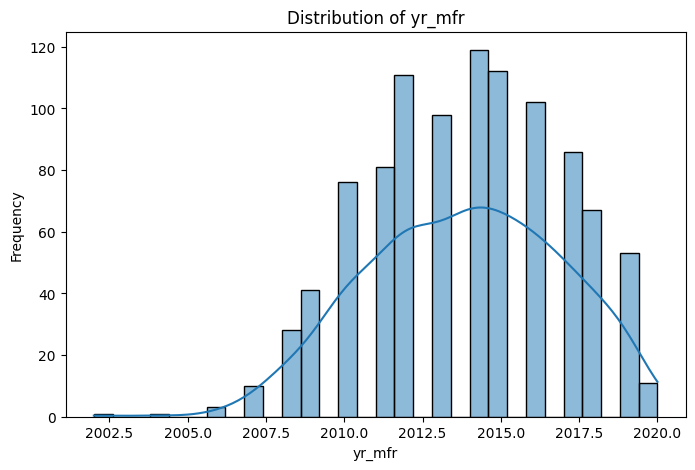

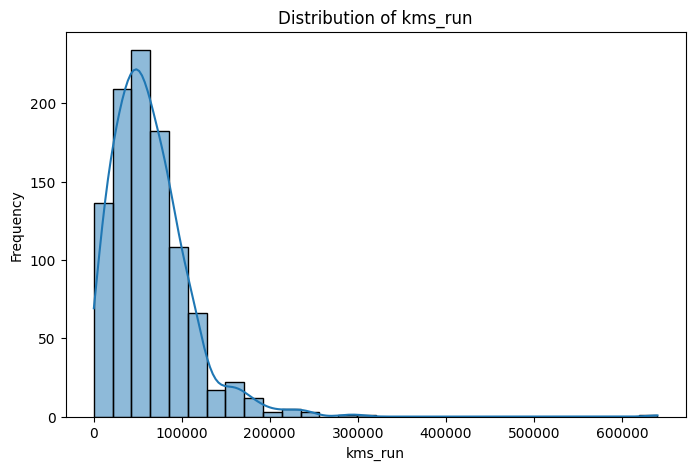

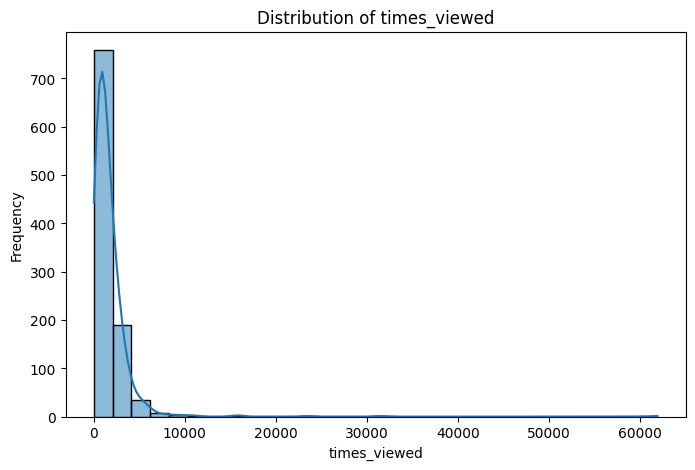

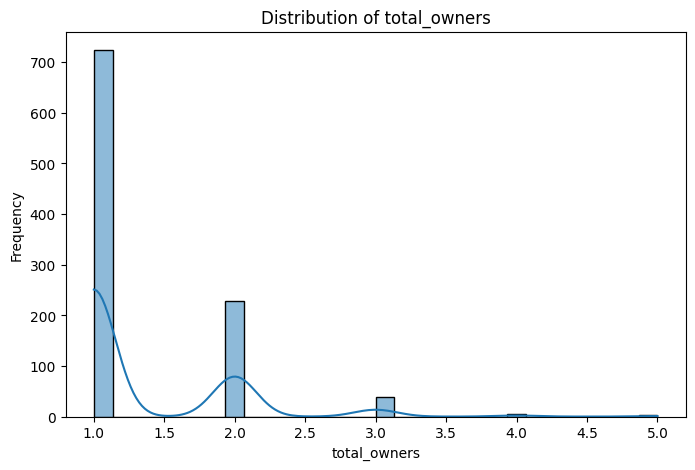

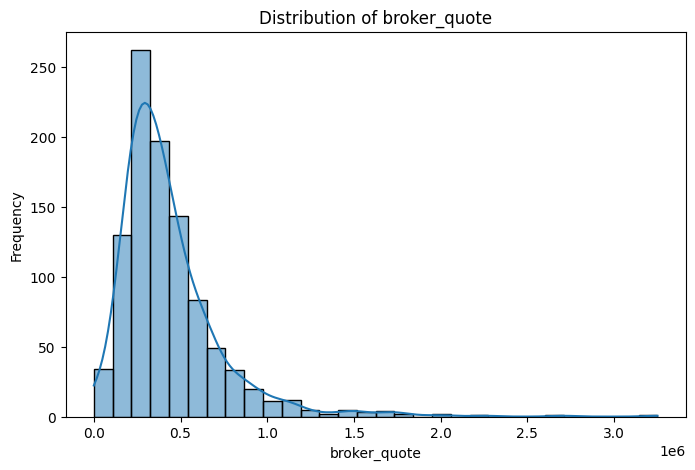

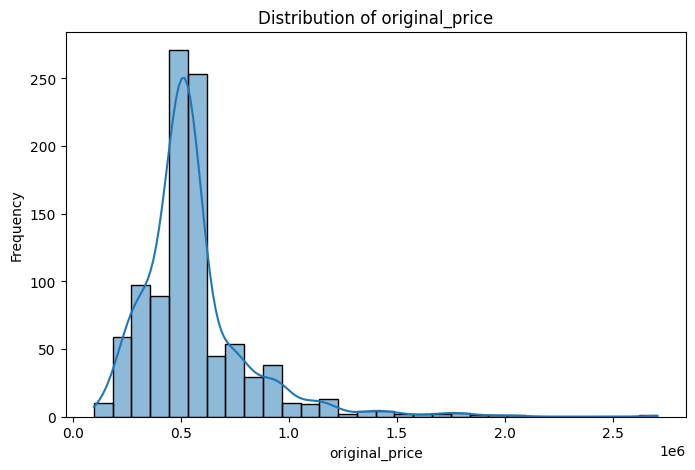

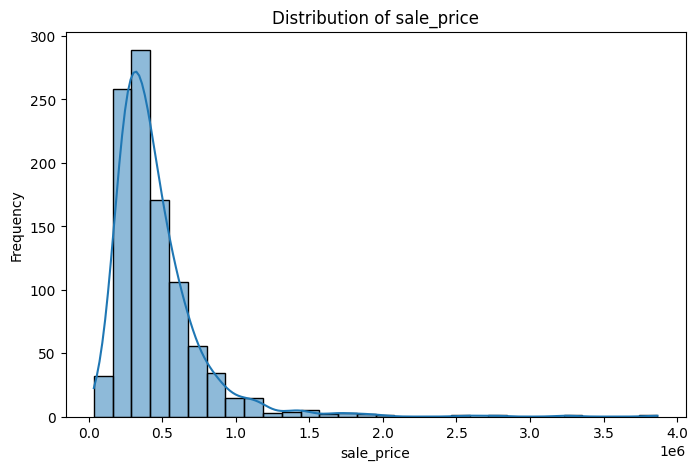

In [ ]:

# List of numerical columns to plot
numerical_columns = ['yr_mfr', 'kms_run', 'times_viewed', 'total_owners',
                     'broker_quote', 'original_price', 'sale_price']

# Plot histograms with KDE for each numerical feature
for column in numerical_columns:
    plt.figure(figsize=(8, 5))
    sns.histplot(df[column], kde=True, bins=30)
    plt.title(f'Distribution of {column}')
    plt.xlabel(column)
    plt.ylabel('Frequency')
    plt.show()


## Boxplots

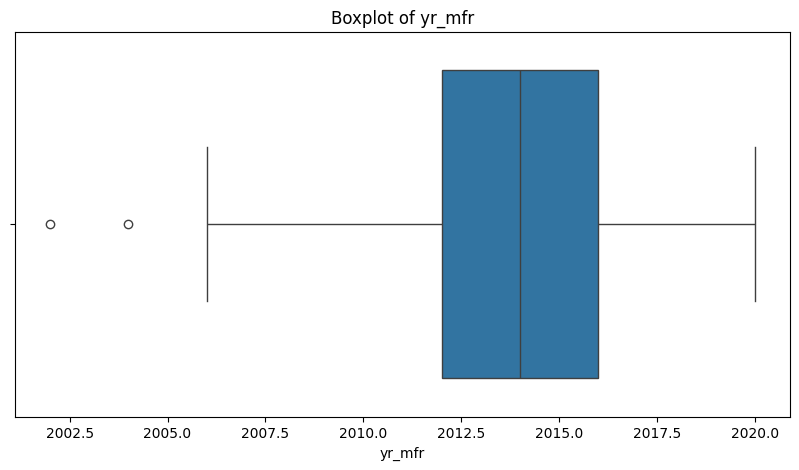

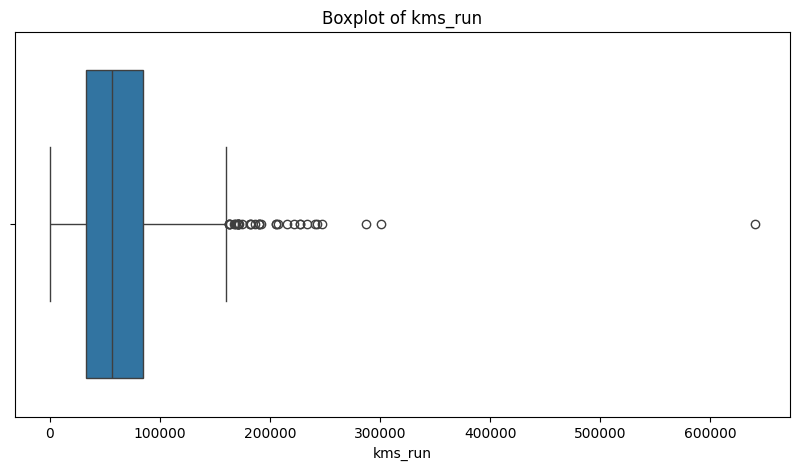

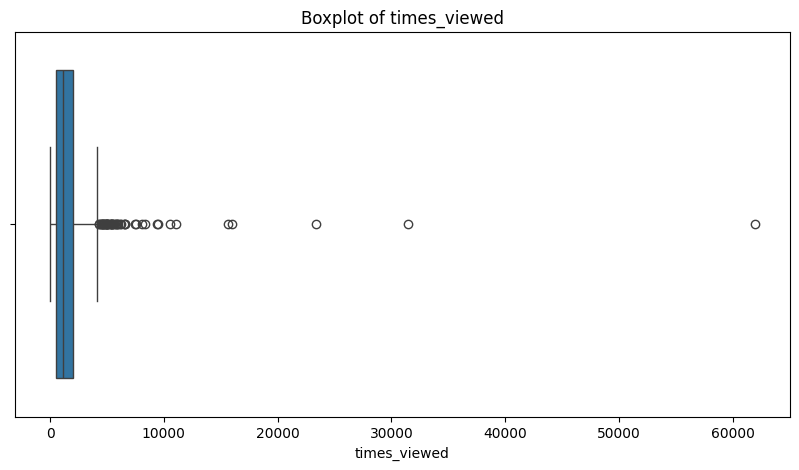

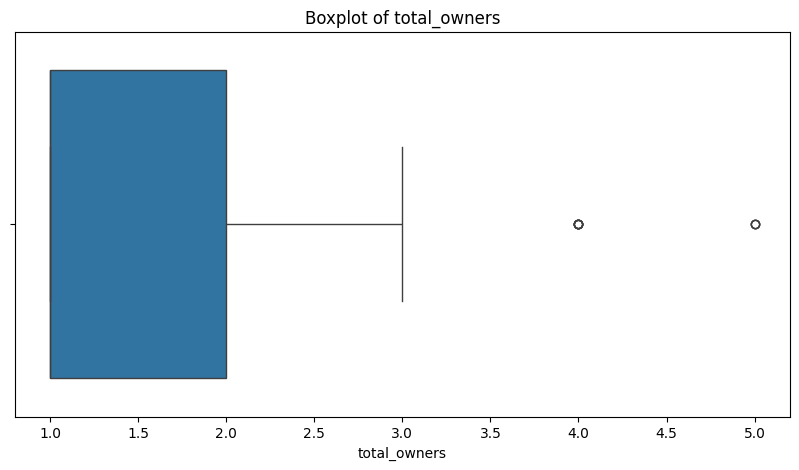

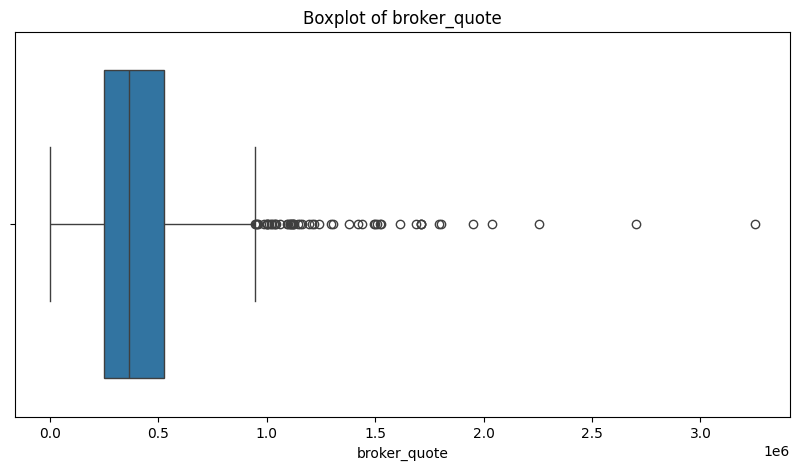

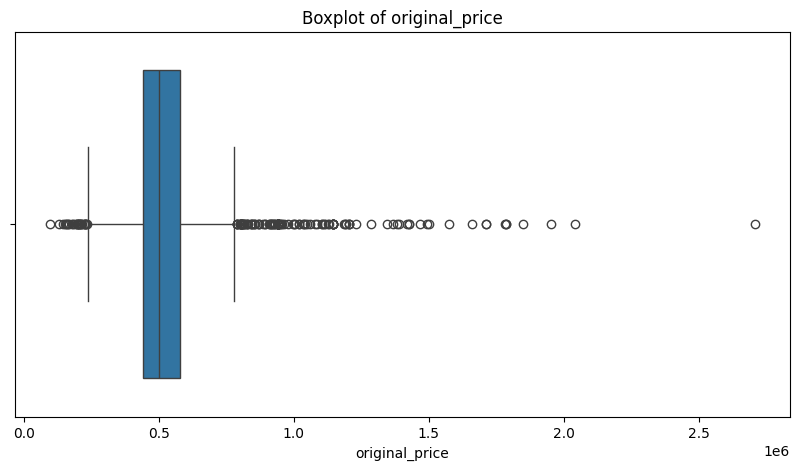

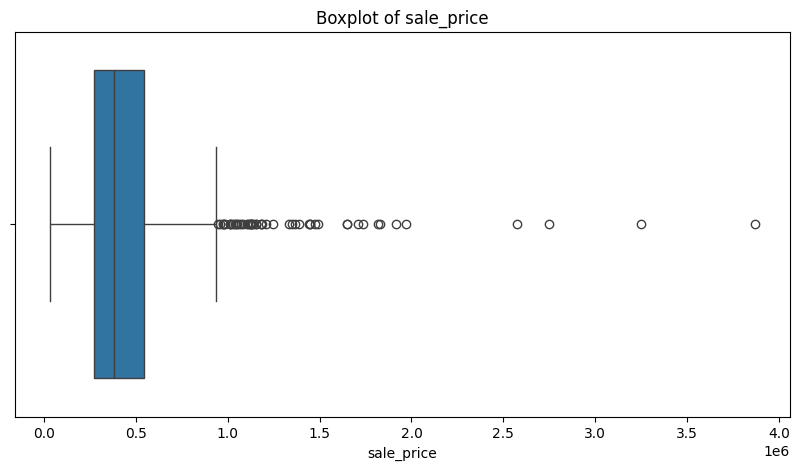

In [ ]:
# Plot boxplots for each numerical feature
for column in numerical_columns:
    plt.figure(figsize=(10, 5))
    sns.boxplot(x=df[column])
    plt.title(f'Boxplot of {column}')
    plt.xlabel(column)
    plt.show()



## Scatterplot


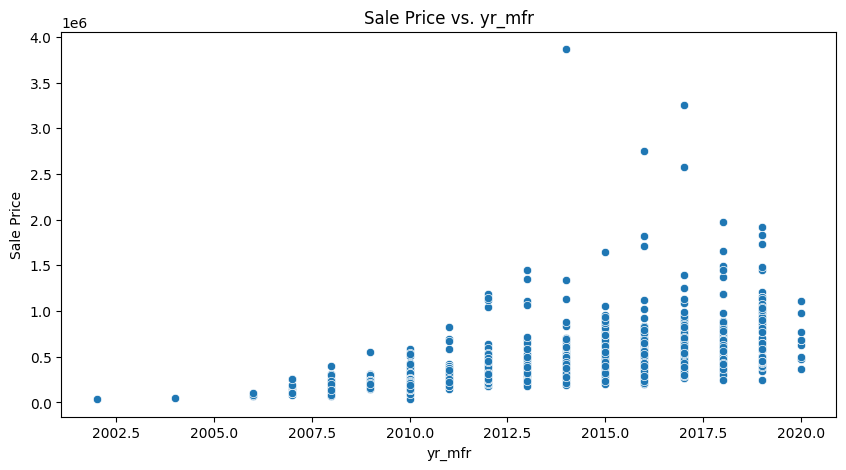

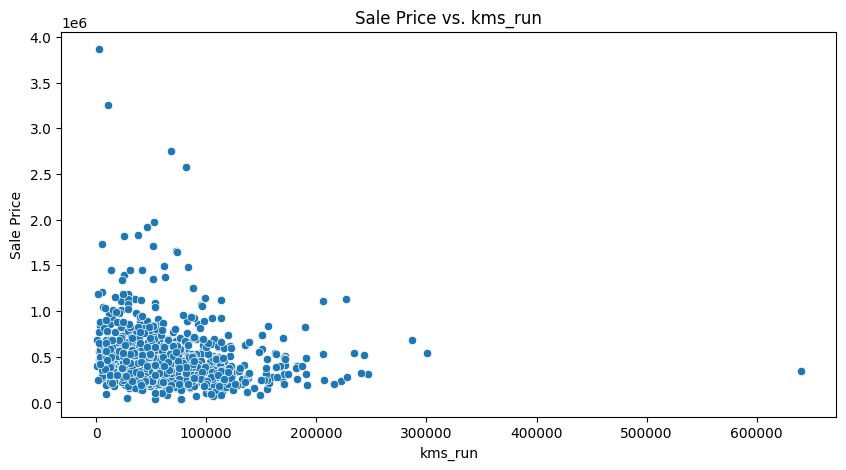

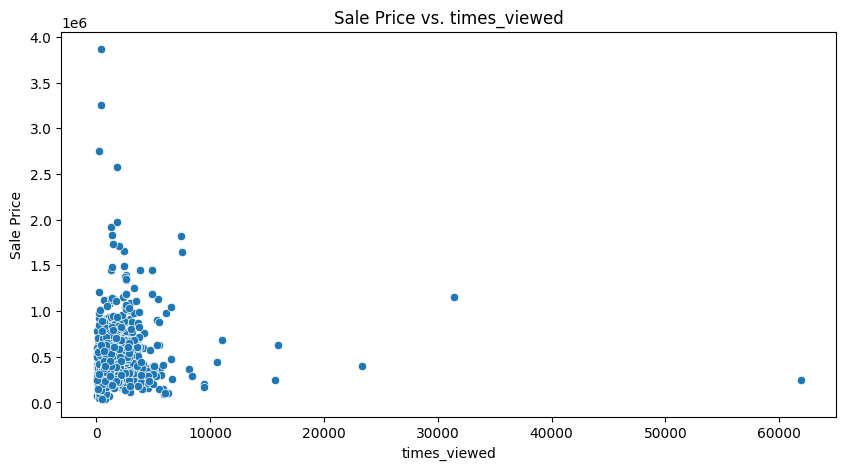

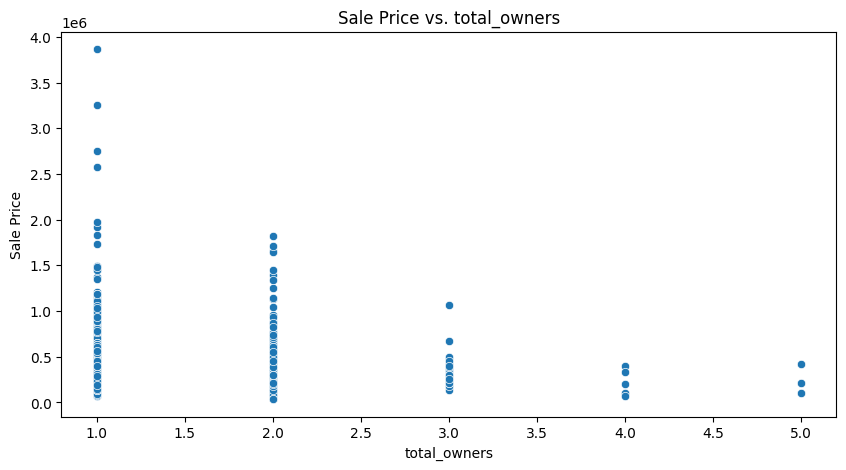

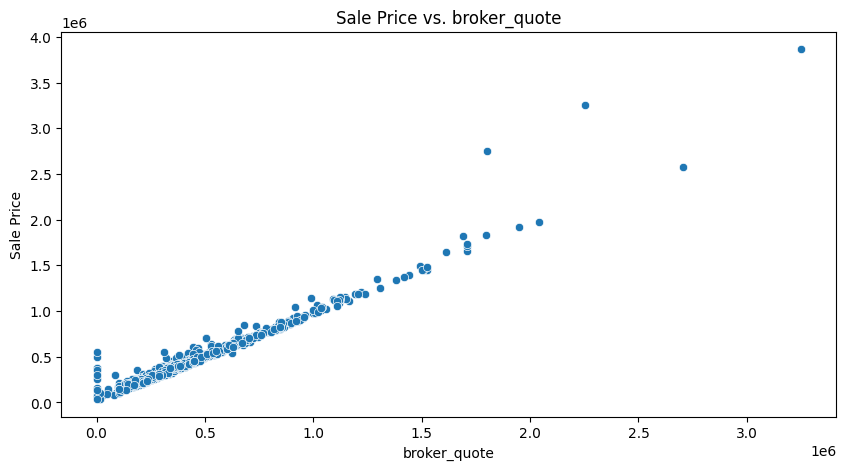

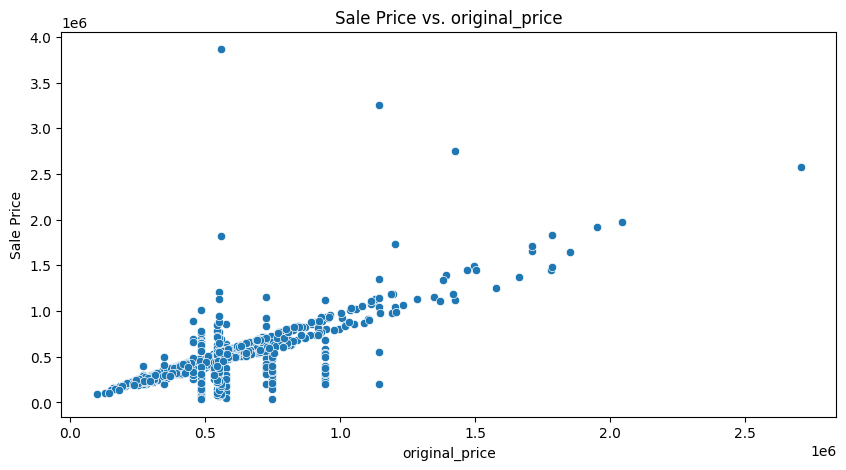

In [ ]:
# Scatter plot of sale_price vs. other numerical features
for column in numerical_columns:
    if column != 'sale_price':
        plt.figure(figsize=(10, 5))
        sns.scatterplot(x=df[column], y=df['sale_price'])
        plt.title(f'Sale Price vs. {column}')
        plt.xlabel(column)
        plt.ylabel('Sale Price')
        plt.show()


## Model

